# Cross-Section Summary â€” All 10 Signals

**Date:** 2023-12-29  
**Universe:** `liquid_500`  
**Scope:** Compute all 10 registered signals on a single date, examine coverage and distributions.

---

### What this notebook does
1. Opens a WRDS connection and builds the `liquid_500` universe as of 2023-12-29.
2. Computes all 10 factors in one pass (one connection, one universe build).
3. Shows a coverage table: how many names have a non-null signal.
4. Shows a histogram grid: signal value distributions.
5. Shows quintile mean tables: sanity-check that the sorts are monotone.
6. Shows pairwise signal rank correlations.
7. Shows top / bottom 5 names per signal.

### Notes
- `idio_vol_252d` requires `crsp_dsf` (daily). Set `SKIP_DAILY_SIGNALS = True` if that table is not refreshed past 2017.
- `beta_60m` requires `ff_factors_monthly`. Run `optlab refresh --table ff_factors_monthly` if the view is missing.
- All other signals use `crsp_msf` (monthly).

## Cell 1 â€” Imports and configuration

In [1]:
import warnings
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

import optlab_research as olr
import optlab_research.workbench as wb

warnings.filterwarnings("ignore", message=".*optionm.*")

# â”€â”€ Configuration â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ASOF          = "2023-12-29"
UNIVERSE_NAME = "liquid_500"

# Flip to False once crsp_dsf is refreshed past 2017.
SKIP_DAILY_SIGNALS = True

ALL_SIGNALS = [
    "book_to_market",
    "gross_profitability",
    "roe",
    "accruals",
    "size",
    "momentum_12_2",
    "short_term_reversal",
    "beta_60m",
    "asset_growth",
    "idio_vol_252d",
]

SIGNALS_TO_RUN = (
    [s for s in ALL_SIGNALS if s != "idio_vol_252d"]
    if SKIP_DAILY_SIGNALS else ALL_SIGNALS
)

if SKIP_DAILY_SIGNALS:
    print("Note: skipping idio_vol_252d (SKIP_DAILY_SIGNALS=True).")
print(f"Signals to compute ({len(SIGNALS_TO_RUN)}): {SIGNALS_TO_RUN}")

Note: skipping idio_vol_252d (SKIP_DAILY_SIGNALS=True).
Signals to compute (9): ['book_to_market', 'gross_profitability', 'roe', 'accruals', 'size', 'momentum_12_2', 'short_term_reversal', 'beta_60m', 'asset_growth']


## Cell 2 â€” Build universe, compute all signals

One connection, one universe build, N signal calls. This is the correct pattern
for multi-signal notebooks â€” building the universe once and reusing it is significantly
faster than opening a new connection per signal.

In [2]:
results = {}   # signal_name -> pl.DataFrame | None

with wb.open() as con:
    univ = wb.universe(UNIVERSE_NAME, ASOF, con=con)
    print(f"Universe '{UNIVERSE_NAME}' as of {ASOF}: {univ.height} names")
    print(f"  price non-null : {univ['mcap_musd'].is_not_null().sum()}")
    print(f"  ceq non-null   : {univ['ceq'].is_not_null().sum()}")
    print(f"  oancf non-null : {univ['oancf'].is_not_null().sum()}")
    print()

    for sig_name in SIGNALS_TO_RUN:
        try:
            df = wb.signal(sig_name, ASOF, universe=univ, con=con)
            results[sig_name] = df
            n_valid = df["signal_value"].is_not_null().sum()
            print(f"  {sig_name:<25} {n_valid:>4} / {len(df)} valid")
        except RuntimeError as e:
            print(f"  {sig_name:<25} SKIPPED: {e}")
            results[sig_name] = None

# active = list of (name, df) pairs where df is not None
active = [(k, v) for k, v in results.items() if v is not None]
print(f"\nDone. {len(active)} signals computed successfully.")

optionm_optcrsphist not registered — skipping optcrsp_link


Universe 'liquid_500' as of 2023-12-29: 500 names
  price non-null : 500
  ceq non-null   : 498
  oancf non-null : 498

  book_to_market             498 / 500 valid
  gross_profitability        498 / 500 valid
  roe                        498 / 500 valid
  accruals                   498 / 500 valid
  size                       500 / 500 valid


  momentum_12_2              498 / 498 valid


  short_term_reversal        499 / 500 valid


  beta_60m                   497 / 497 valid


  asset_growth               497 / 498 valid

Done. 9 signals computed successfully.


## Cell 3 â€” Coverage summary table

In [3]:
rows = []
for sig_name, df in results.items():
    if df is None:
        rows.append({
            "signal": sig_name, "total": None, "non_null": 0,
            "pct_coverage": 0.0, "mean": None, "median": None,
            "std": None, "p5": None, "p95": None,
        })
        continue
    vals  = df["signal_value"].drop_nulls()
    total = len(df)
    nn    = vals.len()
    rows.append({
        "signal":       sig_name,
        "total":        total,
        "non_null":     nn,
        "pct_coverage": round(nn / total * 100, 1) if total > 0 else 0.0,
        "mean":         round(float(vals.mean()), 4)          if nn > 0 else None,
        "median":       round(float(vals.median()), 4)        if nn > 0 else None,
        "std":          round(float(vals.std()), 4)           if nn > 1 else None,
        "p5":           round(float(vals.quantile(0.05)), 4)  if nn > 0 else None,
        "p95":          round(float(vals.quantile(0.95)), 4)  if nn > 0 else None,
    })

summary = pl.DataFrame(rows)
print(summary.to_pandas().to_string(index=False))

             signal  total  non_null  pct_coverage    mean  median     std      p5     p95
     book_to_market    500       498          99.6  0.2963  0.1976  0.3558 -0.0355  0.9000
gross_profitability    500       498          99.6  0.2815  0.2550  0.2089  0.0263  0.6739
                roe    500       498          99.6  0.2786  0.1554  2.0166 -0.7435  0.9723
           accruals    500       498          99.6 -0.0516 -0.0332  0.1195 -0.1769  0.0445
               size    500       500         100.0 10.4343 10.3924  1.1922  8.7005 12.5194
      momentum_12_2    498       498         100.0  2.9517  0.0879 20.0654 -0.8696  8.9819
short_term_reversal    500       499          99.8  0.1086  0.1015  0.1328 -0.0604  0.3137
           beta_60m    497       497         100.0  1.1810  1.0932  0.6960  0.2790  2.3328
       asset_growth    498       497          99.8  0.1172  0.0382  0.5194 -0.1558  0.4050


## Cell 4 â€” Histogram grid

One histogram per signal, winsorized at 1st/99th percentile for display.
Right-skewed distributions (B/M, size) are expected.
Momentum should be roughly symmetric around a positive mean (2023 was a strong year).

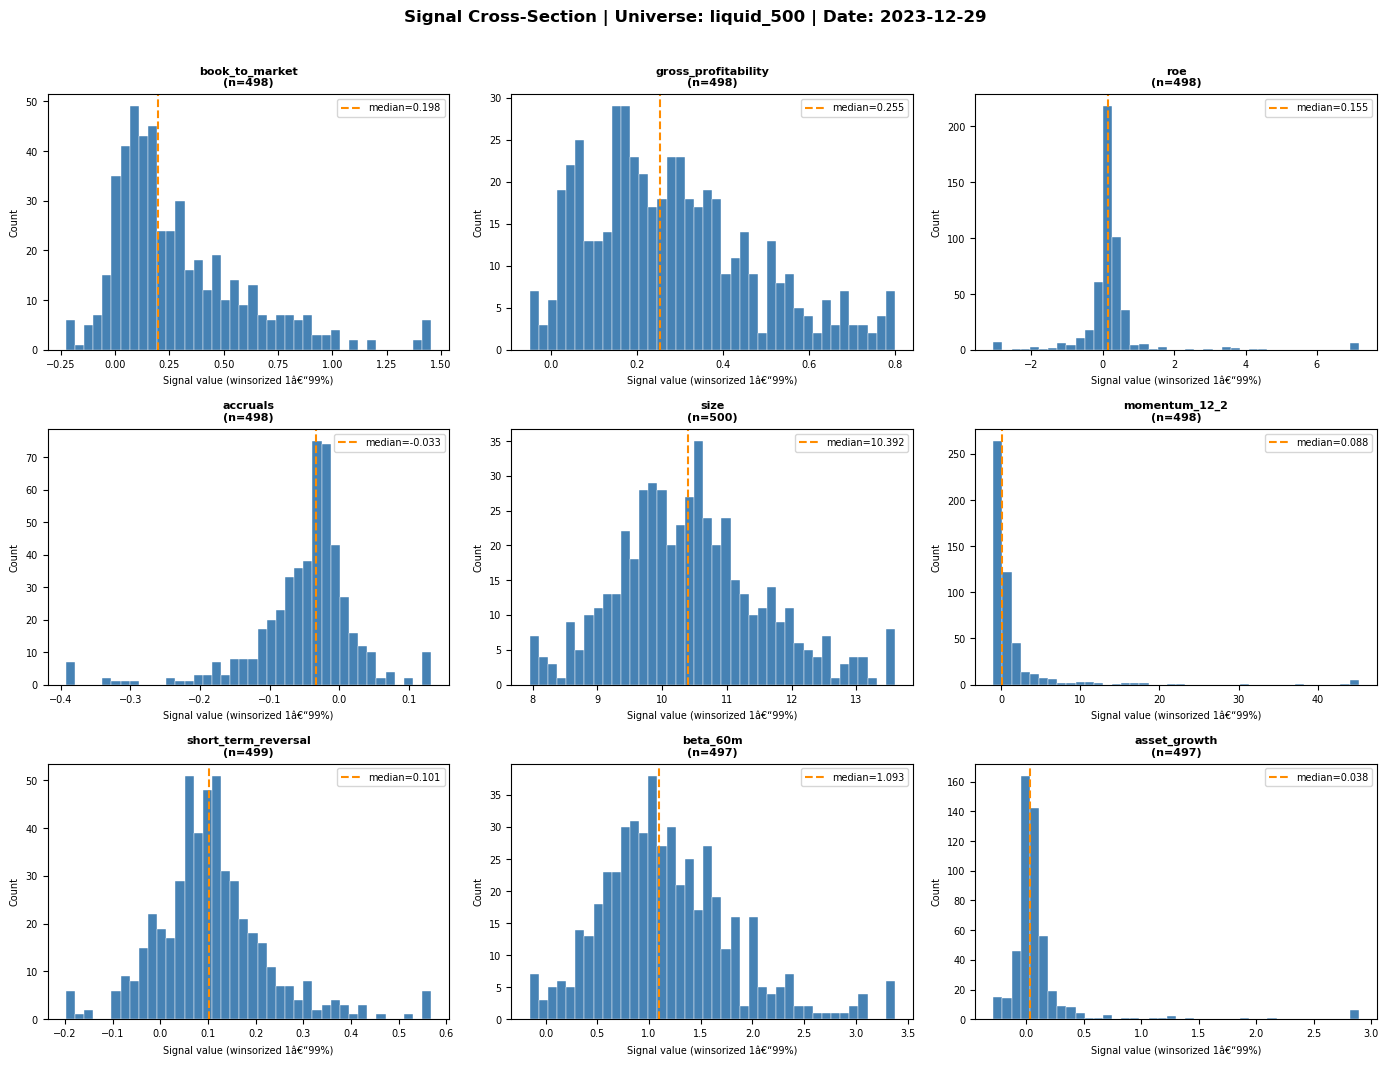

Saved: cross_section_histograms.png


In [4]:
n_signals = len(active)
ncols     = 3
nrows     = (n_signals + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows))
axes_flat = axes.flatten() if n_signals > 1 else [axes]

for i, (sig_name, df) in enumerate(active):
    ax   = axes_flat[i]
    vals = df["signal_value"].drop_nulls().to_numpy()

    p1, p99      = np.percentile(vals, [1, 99])
    vals_clipped = np.clip(vals, p1, p99)
    median_val   = float(np.median(vals_clipped))
    n_valid      = df["signal_value"].is_not_null().sum()

    ax.hist(vals_clipped, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(median_val, color="darkorange", linewidth=1.5,
               linestyle="--", label=f"median={median_val:.3f}")
    ax.set_title(f"{sig_name}\n(n={n_valid})", fontsize=8, fontweight="bold")
    ax.set_xlabel("Signal value (winsorized 1â€“99%)", fontsize=7)
    ax.set_ylabel("Count", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

for j in range(n_signals, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    f"Signal Cross-Section | Universe: {UNIVERSE_NAME} | Date: {ASOF}",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("cross_section_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cross_section_histograms.png")

## Cell 5 â€” Quintile mean tables

For each signal, compute the mean signal value per quintile.
Values should be monotone Q1 < Q2 < Q3 < Q4 < Q5.
Any non-monotone pattern indicates a bug in the ranking logic.

In [5]:
for sig_name, df in active:
    q_means = (
        df
        .filter(pl.col("signal_quantile").is_not_null())
        .group_by("signal_quantile")
        .agg([
            pl.col("signal_value").mean().alias("mean_value"),
            pl.col("signal_value").count().alias("n"),
        ])
        .sort("signal_quantile")
    )

    means       = q_means["mean_value"].to_list()
    is_monotone = all(means[i] <= means[i + 1] for i in range(len(means) - 1))
    flag        = "âœ“" if is_monotone else "âš  NOT MONOTONE"

    print(f"\n{sig_name} {flag}")
    print(q_means.to_pandas().to_string(index=False))


book_to_market âœ“
 signal_quantile  mean_value   n
               1   -0.040710  99
               2    0.102550 100
               3    0.206747  99
               4    0.384280 100
               5    0.824161 100

gross_profitability âœ“
 signal_quantile  mean_value   n
               1    0.029137  99
               2    0.160324 100
               3    0.255010  99
               4    0.365149 100
               5    0.595153 100

roe âœ“
 signal_quantile  mean_value   n
               1   -0.772189  99
               2    0.050773 100
               3    0.156022  99
               4    0.278998 100
               5    1.667709 100

accruals âœ“
 signal_quantile  mean_value   n
               1   -0.182090  99
               2   -0.065119 100
               3   -0.034226  99
               4   -0.015736 100
               5    0.037825 100

size âœ“
 signal_quantile  mean_value   n
               1    8.908857 100
               2    9.803869 100
               3   10.365158 10

## Cell 6 â€” Pairwise signal rank correlations

Cross-sectional Spearman rank correlation between all signal pairs.

Key expectations:
- `book_to_market` â†” `gross_profitability`: **negative** (value vs. quality, Novy-Marx 2013)
- `momentum_12_2` â†” `short_term_reversal`: **negative** (momentum vs. reversal)
- `size` â†” `beta_60m`: **negative** (small caps tend to have higher betas)

Correlations > 0.7 between unrelated signals suggest a data or implementation bug.

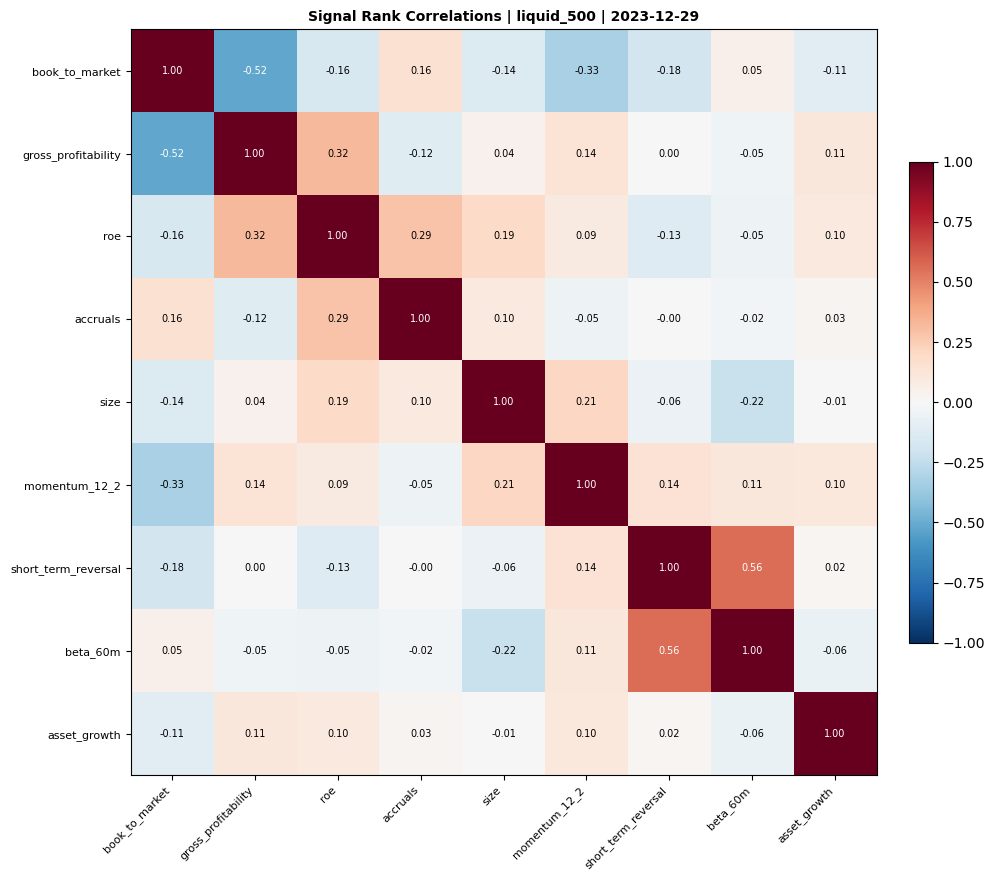

Saved: cross_section_correlations.png


In [6]:
# Join all signal_rank columns on permno.
rank_dfs = [
    df.select(["permno", "signal_rank"]).rename({"signal_rank": sig_name})
    for sig_name, df in active
]

if len(rank_dfs) < 2:
    print("Need at least 2 signals for correlation matrix.")
else:
    combined = rank_dfs[0]
    for rdf in rank_dfs[1:]:
        combined = combined.join(rdf, on="permno", how="full", coalesce=True)

    signal_names = [c for c in combined.columns if c != "permno"]
    n            = len(signal_names)
    corr_matrix  = np.full((n, n), np.nan)

    for i, s1 in enumerate(signal_names):
        for j, s2 in enumerate(signal_names):
            if i == j:
                corr_matrix[i, j] = 1.0
                continue
            # Select two columns by position to avoid duplicate-name error on diagonal.
            pair = (
                combined
                .select([pl.col(s1).alias("x"), pl.col(s2).alias("y")])
                .drop_nulls()
            )
            if len(pair) > 10:
                corr_matrix[i, j] = float(
                    np.corrcoef(pair["x"].to_numpy(), pair["y"].to_numpy())[0, 1]
                )

    fig, ax = plt.subplots(figsize=(n * 0.95 + 1.5, n * 0.95 + 1.5))
    im      = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(signal_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(signal_names, fontsize=8)

    for i in range(n):
        for j in range(n):
            val = corr_matrix[i, j]
            if not np.isnan(val):
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center", fontsize=7,
                    color="white" if abs(val) > 0.5 else "black",
                )

    ax.set_title(
        f"Signal Rank Correlations | {UNIVERSE_NAME} | {ASOF}",
        fontsize=10, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig("cross_section_correlations.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: cross_section_correlations.png")

## Cell 7 â€” Top / bottom 5 names per signal

Spot-check the extremes. Expected:
- **B/M Q5**: deep value / distressed (PARA, C, WBD)
- **Momentum Q5**: strongest 12-month performers
- **Size Q1**: smallest-cap names in the universe
- **Accruals Q1**: most cash-based earners (lowest accruals = long side)
- **Asset growth Q1**: asset shrinkers (lowest growth = long side)

In [7]:
# Re-open connection to get ticker map.
# In production, pass `univ` through from Cell 2 instead of re-querying.
with wb.open() as con:
    univ_tickers = wb.universe(UNIVERSE_NAME, ASOF, con=con)

ticker_map = univ_tickers.select(
    [pl.col("permno").cast(pl.Int64), "ticker", "name"]
)

for sig_name, df in active:
    enriched = (
        df
        .filter(pl.col("signal_value").is_not_null())
        .join(ticker_map, on="permno", how="left")
    )

    top5 = enriched.sort("signal_value", descending=True).head(5)
    bot5 = enriched.sort("signal_value").head(5)
    cols = ["ticker", "name", "signal_value", "signal_quantile"]

    print(f"\n{'â”€' * 68}")
    print(f"{sig_name} â€” Top 5")
    print(top5.select(cols).to_pandas().to_string(index=False))
    print(f"\n{sig_name} â€” Bottom 5")
    print(bot5.select(cols).to_pandas().to_string(index=False))

optionm_optcrsphist not registered — skipping optcrsp_link


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
book_to_market â€” Top 5
ticker                      name  signal_value  signal_quantile
  PARA          PARAMOUNT GLOBAL      2.544998                5
  MULN     MULLEN AUTOMOTIVE INC      2.484665                5
     C             CITIGROUP INC      1.850623                5
   WBD WARNER BROS DISCOVERY INC      1.696761                5
   RUN                SUNRUN INC      1.557614                5

book_to_market â€” Bottom 5
ticker                             name  signal_value  signal_quantile
   AMC A M C ENTERTAINMENT HOLDINGS INC     -2.161960                1
   AAL      AMERICAN AIRLINES GROUP INC     -0.645071                1
     W                      WAYFAIR INC     -0.447982                1
   DPZ                DOMINOS PIZZA INC     -0.291332                1
 